In [82]:
!pip install --quiet diffusers transformers accelerate matplotlib pillow

In [83]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import os

In [84]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [85]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"

if DEVICE == "cuda":
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16  # Half-precision: halves VRAM usage on GPU
    )
else:
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float32  # Full-precision: required for CPU compatibility
    )
pipe = pipe.to(DEVICE)

print("Model loaded and ready!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded and ready!


In [132]:
PROMPT = (
    "Ultra-realistic photograph of an astronaut up close standing on the lunar surface "
    "sharp focus, dramatic sunlight and deep shadows, realistic moon dust and footprints, "
    "cinematic composition, shot on 85mm lens, f/2.8, HDR, global illumination, "
    "8k resolution, photorealistic, volumetric lighting, crisp details, hyper-detailed"
)

NEGATIVE_PROMPT = (
    "blurry, low resolution, noise, grain, soft focus, out of focus, distorted anatomy, "
    "deformed, bad proportions, extra limbs, unrealistic lighting, oversaturated, "
    "cartoon, anime, illustration, painting, CGI, 3d render, watermark, text, logo, artifacts"
)
print("Prompt defined:")
print(f"   Positive: {PROMPT}")
print(f"   Negative: {NEGATIVE_PROMPT}")

Prompt defined:
   Positive: Ultra-realistic photograph of an astronaut up close standing on the lunar surface sharp focus, dramatic sunlight and deep shadows, realistic moon dust and footprints, cinematic composition, shot on 85mm lens, f/2.8, HDR, global illumination, 8k resolution, photorealistic, volumetric lighting, crisp details, hyper-detailed
   Negative: blurry, low resolution, noise, grain, soft focus, out of focus, distorted anatomy, deformed, bad proportions, extra limbs, unrealistic lighting, oversaturated, cartoon, anime, illustration, painting, CGI, 3d render, watermark, text, logo, artifacts


In [133]:
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 7.5
SEED = 42
IMAGE_HEIGHT = 1080
IMAGE_WIDTH  = 1920

print("  Generation parameters:")
print(f"   Steps:          {NUM_INFERENCE_STEPS}")
print(f"   Guidance Scale: {GUIDANCE_SCALE}")
print(f"   Seed:           {SEED}")
print(f"   Resolution:     {IMAGE_WIDTH} x {IMAGE_HEIGHT} px")

  Generation parameters:
   Steps:          30
   Guidance Scale: 7.5
   Seed:           42
   Resolution:     1920 x 1080 px


In [134]:
print(f"Starting image generation ({NUM_INFERENCE_STEPS} denoising steps)...\n")
generator = torch.Generator(device=DEVICE).manual_seed(SEED)
result = pipe(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    height=IMAGE_HEIGHT,
    width=IMAGE_WIDTH,
    generator=generator
)
image = result.images[0]

print("Image generation complete!")
print(f"Image size: {image.size[0]} x {image.size[1]} pixels")

Starting image generation (30 denoising steps)...



  0%|          | 0/30 [00:00<?, ?it/s]

Image generation complete!
Image size: 1920 x 1080 pixels


In [135]:
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "generated_image.png")
image.save(output_path)

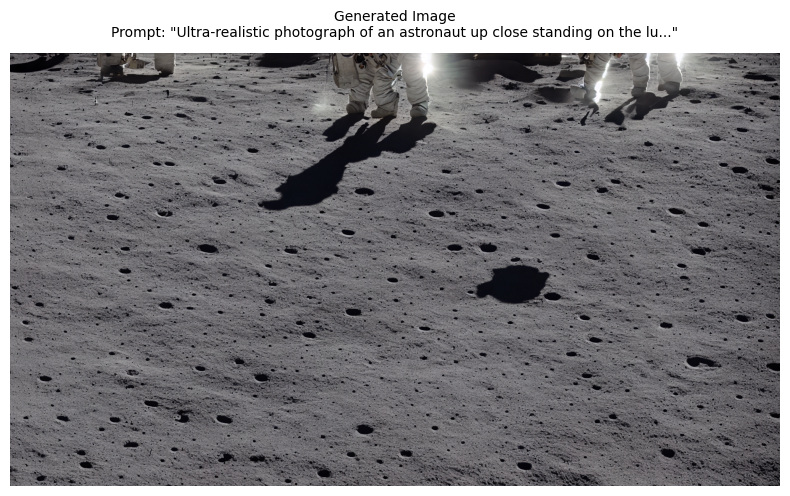

In [136]:
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Generated Image\nPrompt: \"{PROMPT[:70]}...\"",
    fontsize=10,
    pad=12
)
plt.tight_layout()
plt.show()